# Hallucination Measurement Notebook — All Models Comparison

**Research Question:** Does the emotional framing of a factual question influence hallucination rates in transformer-based LLMs?

**Models compared:**
- `google/flan-t5-large` (~780M parameters, seq2seq)
- `mistralai/Mistral-7B-Instruct-v0.3` (7B, 4-bit quantized, causal)
- `tiiuae/falcon-7b-instruct` (7B, fp16, causal)
- `meta-llama/Meta-Llama-3-8B-Instruct` (8B, 4-bit quantized, causal)
- `microsoft/Phi-3-mini-4k-instruct` (3.8B, GGUF q4, causal)

**Dataset:** `belpekkan/emotion-framed-factual-qa` (823 validated stimuli)

**Structure:**
1. Setup & Imports
2. Load Dataset
3. Shared Helper Functions (`normalise`, `score_response`, `classify_hallucination`, `run_scoring`, `compute_stats`, `run_statistical_tests`, `run_inference_with_checkpointing`)
4. Model-specific: FLAN-T5 — Load, Inference, Score
5. Model-specific: Mistral — Load, Inference, Score
6. Model-specific: Falcon — Load, Inference, Score
7. Model-specific: Llama-3 — Load, Inference, Score
8. Model-specific: Phi-3 Mini — Load, Inference, Score
9. Per-Model Summary Statistics
10. Cross-Model Comparison Plots
11. Statistical Analysis (per model + cross-model summary)
12. Qualitative Analysis — emotion-induced errors


---
## Section 1 — Setup & Installations

> **Note on Falcon version pins:** Falcon requires `transformers==4.36.2` and `sentence-transformers==2.7.0` to avoid a `get_head_mask` AttributeError.

In [ ]:
# Install dependencies
# Pin transformers==4.36.2 for Falcon compatibility (also works for FLAN-T5 and Mistral)
!pip install -q transformers==4.36.2 sentence-transformers==2.7.0
!pip install -q datasets bitsandbytes accelerate huggingface_hub
!pip install -q matplotlib seaborn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.1 MB/s eta 0:00:00


In [ ]:
import os
import json
import re
import string
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
from itertools import combinations
from scipy.stats import chi2_contingency

from huggingface_hub import login
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    T5TokenizerFast,
    BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer, util

# hared configurations
HF_TOKEN           = os.environ.get('HF_TOKEN')
DATASET_ID         = 'belpekkan/emotion-framed-factual-qa'
SEMANTIC_THRESHOLD = 0.75
MAX_NEW_TOKENS     = 50
CHECKPOINT_EVERY   = 50

EMOTION_ORDER = ['neutral', 'joy', 'sadness', 'anger', 'fear']
DOMAIN_ORDER  = ['geography', 'history', 'science', 'culture']

if HF_TOKEN:
    login(token=HF_TOKEN)
    print('Logged in to HuggingFace')
else:
    print('No HF_TOKEN found — proceeding without login')

print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

import transformers
print(f'transformers version: {transformers.__version__}')

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


No HF_TOKEN found — proceeding without login
GPU available: True
GPU: NVIDIA A100-SXM4-40GB
transformers version: 4.36.2


In [ ]:
# Model and nice plotting configs
# Model colours
MODEL_COLORS = {
    "FLAN-T5": "#c084fc",   # violet
    "Mistral":  "#f472b6",   # pink
    "Falcon":   "#e879f9",   # fuchsia
    "Llama-3":  "#818cf8",   # indigo
    "Phi-3":    "#fb7185",   # rose
}
MODELS = list(MODEL_COLORS.keys())
COLORS = list(MODEL_COLORS.values())

# Hallucination-type colours
TYPE_COLORS = {
    "substitution":  "#a855f7",
    "confabulation": "#ec4899",
    "uncertainty":   "#818cf8",
    "refusal_empty": "#ddd6fe",
}

INK   = "#1a1a2e"
INK2  = "#2d2d4e"
MUTED = "#6b6b8a"
CARD  = "#ffffff"
GRID  = "#e2dff0"

# Global rcParams
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.facecolor":     CARD,
    "figure.facecolor":   CARD,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     GRID,
    "axes.grid":          True,
    "grid.color":         GRID,
    "grid.linewidth":     0.5,
    "grid.alpha":         0.8,
    "xtick.color":        MUTED,
    "ytick.color":        MUTED,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "axes.labelcolor":    MUTED,
    "axes.titlecolor":    INK2,
    "axes.titlesize":     9,
    "axes.titleweight":   "bold",
    "axes.titlepad":      7,
})

SAVEKW = dict(dpi=300, bbox_inches="tight", facecolor=CARD, edgecolor="none")
print("Palette and style configured.")


Palette and style configured.


---
## Section 2 — Load Dataset from HuggingFace

Load the 823 validated stimuli.

In [ ]:
hf_dataset = load_dataset(DATASET_ID, split='train')
df = hf_dataset.to_pandas()

def parse_aliases(val):
    if isinstance(val, list):
        return val
    try:
        return json.loads(val)
    except Exception:
        return [str(val)]

df['answer_aliases'] = df['answer_aliases'].apply(parse_aliases)

print(f'Dataset loaded: {len(df)} rows')
print(f'\nEmotion condition counts:')
print(df['emotion_condition'].value_counts())
print(f'\nTopic domain counts:')
print(df['topic_domain'].value_counts())
df.head(3)

README.md: 0.00B [00:00, ?B/s]

emotion_framed_qa_validated.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/823 [00:00<?, ? examples/s]

Dataset loaded: 823 rows

Emotion condition counts:
emotion_condition
neutral    240
sadness    200
fear       185
anger      118
joy         80
Name: count, dtype: int64

Topic domain counts:
topic_domain
geography    210
culture      206
science      204
history      203
Name: count, dtype: int64


,question_id,original_question,rewritten_question,emotion_condition,ground_truth,answer_aliases,topic_domain,validation_score,top_detected_emotion,validation_passed
0,qb_7598,What is the name of the island which lies in t...,What is the name of the island which lies in t...,neutral,Goat Island,"[['Goat Island (disambiguation)', 'Goat Island...",geography,1.0000,neutral,True
1,qb_7598,What is the name of the island which lies in t...,It saddens me how little I remember... what is...,sadness,Goat Island,"[['Goat Island (disambiguation)', 'Goat Island...",geography,0.9983,sadness,True
2,qb_7598,What is the name of the island which lies in t...,I'm terrified I'll get this wrong — what is th...,fear,Goat Island,"[['Goat Island (disambiguation)', 'Goat Island...",geography,0.9582,fear,True


---
## Section 3 — Shared Helper Functions

Defined **once**, reused across all models for consistency:
- `normalise()` — text normalisation
- `score_response()` — 4-layer correctness pipeline (exact / alias / normalised / semantic)
- `classify_hallucination()` — error type labelling
- `run_scoring()` — applies scoring to a full dataframe
- `compute_stats()` — computes emotion / domain hallucination rate tables
- `run_statistical_tests()` — chi-squared + Cramér's V + Bonferroni domain comparisons
- `run_inference_with_checkpointing()` — generic inference loop with checkpoint saving

In [ ]:
# Load semantic similarity model to be used in all the models
sem_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Semantic model loaded')

Loading semantic similarity model (shared across all model runs)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic model loaded ✓


In [ ]:
# Text normalisation
def normalise(text: str) -> str:
    #Lowercase, remove articles and punctuation, collapse whitespace.
    text = text.lower().strip()
    text = re.sub(r'\b(a|an|the)\b', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# 4-layer correctness pipeline
def score_response(response: str, ground_truth: str, aliases: list) -> dict:
    # Run 4-layer correctness check

    response_clean = response.strip()
    all_answers = [ground_truth] + (aliases if isinstance(aliases, list) else [])

    # Layer 1: Exact match
    if any(response_clean.lower() == ans.lower() for ans in all_answers):
        return {'is_correct': True, 'match_level': 'exact'}

    # Layer 2: Alias match (response contains the answer)
    import re
    if any(re.search(rf'\b{re.escape(ans.lower())}\b', response_clean.lower()) for ans in all_answers):
      return {'is_correct': True, 'match_level': 'alias_contained'}

    # Layer 3: Normalised match
    norm_response = normalise(response_clean)
    if any(normalise(ans) == norm_response for ans in all_answers):
        return {'is_correct': True, 'match_level': 'normalised'}

    # Layer 4: Semantic similarity
    response_emb = sem_model.encode(response_clean, convert_to_tensor=True)
    answer_embs  = sem_model.encode(all_answers,    convert_to_tensor=True)
    cos_scores   = util.cos_sim(response_emb, answer_embs)[0]
    if cos_scores.max().item() >= SEMANTIC_THRESHOLD:
        return {'is_correct': True, 'match_level': 'semantic'}

    return {'is_correct': False, 'match_level': 'incorrect'}


# Hallucination type classifier
def classify_hallucination(response: str) -> str:
    # Classify the error type for incorrect responses.

    if not response or len(response.strip()) < 2:
        return 'refusal_or_empty'
    uncertainty_markers = [
        "i don't know", "i'm not sure", 'i cannot', 'unknown',
        'maybe', 'possibly', 'perhaps', 'i think', 'probably', 'unclear'
    ]
    if any(p in response.lower() for p in uncertainty_markers):
        return 'uncertainty'
    if len(response.split()) > 15:
        return 'confabulation'
    return 'substitution'


# Apply scoring to a full dataframe
def run_scoring(df_in: pd.DataFrame) -> pd.DataFrame:
    #Apply score_response and classify_hallucination to every row.

    is_correct_list    = []
    match_level_list   = []
    hallucination_list = []

    for _, row in tqdm(df_in.iterrows(), total=len(df_in), desc='Scoring'):
        aliases = (
            json.loads(row['answer_aliases'])
            if isinstance(row['answer_aliases'], str)
            else row['answer_aliases']
        )
        result = score_response(row['model_response'], row['ground_truth'], aliases)
        is_correct_list.append(result['is_correct'])
        match_level_list.append(result['match_level'])
        hallucination_list.append(
            'correct' if result['is_correct']
            else classify_hallucination(row['model_response'])
        )

    out = df_in.copy()
    out['is_correct']         = is_correct_list
    out['match_level']        = match_level_list
    out['hallucination_type'] = hallucination_list
    return out


# Summary statistics
def compute_stats(df_in: pd.DataFrame):
    #Compute emotion-level and domain-level hallucination rate tables.

    emotion_stats = (
        df_in.groupby('emotion_condition')['is_correct']
        .agg(n='count', correct='sum')
        .assign(
            accuracy=lambda x: x['correct'] / x['n'],
            hallucination_rate=lambda x: 1 - x['correct'] / x['n']
        )
        .reindex(EMOTION_ORDER)
        .reset_index()
    )
    neutral_hr = emotion_stats.loc[
        emotion_stats['emotion_condition'] == 'neutral', 'hallucination_rate'
    ].values[0]
    emotion_stats['delta_from_neutral'] = emotion_stats['hallucination_rate'] - neutral_hr

    domain_stats = (
        df_in.groupby('topic_domain')['is_correct']
        .agg(n='count', correct='sum')
        .assign(hallucination_rate=lambda x: 1 - x['correct'] / x['n'])
        .reindex(DOMAIN_ORDER)
        .reset_index()
    )
    return emotion_stats, domain_stats, neutral_hr


# Statistical tests
def run_statistical_tests(df_in: pd.DataFrame, model_name: str) -> dict:
    # Run chi-squared + Cramer's V for emotion and domain effects.
    # Also prints Bonferroni-corrected pairwise domain comparisons.

    # Emotion chi-squared
    contingency = (
        df_in.groupby('emotion_condition')['is_correct']
        .value_counts().unstack(fill_value=0)
        .reindex(EMOTION_ORDER)
        .rename(columns={True: 'correct', False: 'incorrect'})
        [['correct', 'incorrect']]
    )
    table = contingency.values
    chi2_e, p_e, dof_e, _ = chi2_contingency(table)
    n_e   = table.sum()
    v_e   = np.sqrt(chi2_e / (n_e * min(table.shape[0] - 1, table.shape[1] - 1)))
    interp_e = (
        'negligible' if v_e < 0.10 else 'small' if v_e < 0.20
        else 'medium' if v_e < 0.40 else 'large'
    )

    # Domain chi-squared
    domain_contingency = (
        df_in.groupby('topic_domain')['is_correct']
        .value_counts().unstack(fill_value=0)
        .reindex(DOMAIN_ORDER)
        .rename(columns={True: 'correct', False: 'incorrect'})
        [['correct', 'incorrect']]
    )
    d_table = domain_contingency.values
    chi2_d, p_d, dof_d, _ = chi2_contingency(d_table)
    n_d   = d_table.sum()
    v_d   = np.sqrt(chi2_d / (n_d * min(d_table.shape[0] - 1, d_table.shape[1] - 1)))
    interp_d = (
        'negligible' if v_d < 0.10 else 'small' if v_d < 0.20
        else 'medium' if v_d < 0.40 else 'large'
    )

    print(f'\n{"="*60}')
    print(f'STATISTICAL TESTS — {model_name}')
    print(f'{"="*60}')
    print(f'  Emotion: chi2({dof_e}) = {chi2_e:.3f}, p = {p_e:.4f}, V = {v_e:.3f} ({interp_e})')
    print(f'  Domain:  chi2({dof_d}) = {chi2_d:.3f}, p = {p_d:.4f}, V = {v_d:.3f} ({interp_d})')

    domain_pairs     = list(combinations(DOMAIN_ORDER, 2))
    alpha_bonferroni = 0.05 / len(domain_pairs)
    print(f'\n  Pairwise domain comparisons (Bonferroni alpha = {alpha_bonferroni:.4f}):')
    for d1, d2 in domain_pairs:
        sub = domain_contingency.loc[[d1, d2], ['correct', 'incorrect']].values
        chi2_p, p_p, _, _ = chi2_contingency(sub)
        sig = '*' if p_p < alpha_bonferroni else 'ns'
        print(f'    {d1:12s} vs {d2:12s}: chi2={chi2_p:.3f}, p={p_p:.4f}  {sig}')
    print('  (* = significant after Bonferroni correction)')

    return {
        'model':   model_name,
        'chi2_e':  chi2_e, 'p_e':   p_e, 'dof_e': dof_e, 'v_e':   v_e, 'interp_e': interp_e,
        'chi2_d':  chi2_d, 'p_d':   p_d, 'dof_d': dof_d, 'v_d':   v_d, 'interp_d': interp_d,
    }


# Generic inference loop with checkpointing
def run_inference_with_checkpointing(
    df_source: pd.DataFrame,
    generate_fn,
    checkpoint_file: str
) -> pd.DataFrame:
    # Actually runs the inference with checkpoints

    checkpoint_path = Path(checkpoint_file)
    if checkpoint_path.exists():
        df_done   = pd.read_csv(checkpoint_path)
        done_idx  = set(df_done['original_index'].tolist())
        print(f'Resuming from checkpoint: {len(done_idx)} rows already completed.')
    else:
        df_done  = pd.DataFrame()
        done_idx = set()
        print('No checkpoint found — starting fresh.')

    new_rows    = []
    rows_to_run = df_source[~df_source.index.isin(done_idx)]
    print(f'Running inference on {len(rows_to_run)} remaining rows...')

    for i, (idx, row) in enumerate(tqdm(rows_to_run.iterrows(), total=len(rows_to_run))):
        try:
            response = generate_fn(row['rewritten_question'])
        except Exception as e:
            print(f'  Error at row {idx}: {e}')
            response = '[ERROR]'

        aliases_val = row['answer_aliases']
        new_rows.append({
            'original_index':     idx,
            'question_id':        row['question_id'],
            'original_question':  row['original_question'],
            'rewritten_question': row['rewritten_question'],
            'emotion_condition':  row['emotion_condition'],
            'topic_domain':       row['topic_domain'],
            'ground_truth':       row['ground_truth'],
            'answer_aliases':     json.dumps(aliases_val) if isinstance(aliases_val, list) else aliases_val,
            'model_response':     response,
        })

        if (i + 1) % CHECKPOINT_EVERY == 0:
            pd.concat([df_done, pd.DataFrame(new_rows)], ignore_index=True
                      ).to_csv(checkpoint_path, index=False)
            print(f'  Checkpoint saved at row {i + 1}')

    df_all = pd.concat([df_done, pd.DataFrame(new_rows)], ignore_index=True)
    df_all.to_csv(checkpoint_path, index=False)
    print(f'Inference complete. Total rows: {len(df_all)}')
    return df_all


print('All shared helper functions defined ✓')

All shared helper functions defined ✓


---
## Section 4 — FLAN-T5 Large

In [ ]:
FLAN_MODEL_ID   = 'google/flan-t5-large'
FLAN_CHECKPOINT = 'checkpoint_flant5.csv'
FLAN_OUTPUT     = 'hallucination_results_flant5.csv'

print(f'Loading {FLAN_MODEL_ID}...')
flan_tokenizer = T5TokenizerFast.from_pretrained(FLAN_MODEL_ID)
flan_model = AutoModelForSeq2SeqLM.from_pretrained(
    FLAN_MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='auto' if torch.cuda.is_available() else None
)
flan_model.eval()
print('FLAN-T5 loaded ✓')

Loading google/flan-t5-large...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 loaded ✓


In [ ]:
def flan_generate(question: str) -> str:
    #Flan-T5 does not use chat templates. Direct instruction + question.

    prompt = (
        'You are a factual question-answering assistant. '
        'Answer the following question in as few words as possible. '
        'Give only the answer — no explanation, no preamble.\n\n'
        + question
    )
    inputs = flan_tokenizer(prompt, return_tensors='pt',
                            truncation=True, max_length=512)
    if torch.cuda.is_available():
        inputs = {k: v.to('cuda') for k, v in inputs.items()}
    with torch.no_grad():
        output_ids = flan_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=flan_tokenizer.pad_token_id
        )
    return flan_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

df_flan_raw = run_inference_with_checkpointing(df, flan_generate, FLAN_CHECKPOINT)

Resuming from checkpoint: 823 rows already completed.
Running inference on 0 remaining rows...


0it [00:00, ?it/s]

Inference complete. Total rows: 823


In [ ]:
df_flan_raw['model_response'] = df_flan_raw['model_response'].astype(str)
df_flan = run_scoring(df_flan_raw)
df_flan.to_csv(FLAN_OUTPUT, index=False)

print(f'FLAN-T5 accuracy:           {df_flan["is_correct"].mean():.1%}')
print(f'FLAN-T5 hallucination rate: {1 - df_flan["is_correct"].mean():.1%}')

flan_emotion_stats, flan_domain_stats, flan_neutral_hr = compute_stats(df_flan)
print('\nEmotion stats:')
print(flan_emotion_stats[['emotion_condition', 'n', 'hallucination_rate', 'delta_from_neutral']].to_string(index=False))
print('\nDomain stats:')
print(flan_domain_stats[['topic_domain', 'n', 'hallucination_rate']].to_string(index=False))

Scoring:   0%|          | 0/823 [00:00<?, ?it/s]

FLAN-T5 accuracy:           21.4%
FLAN-T5 hallucination rate: 78.6%

Emotion stats:
emotion_condition   n  hallucination_rate  delta_from_neutral
          neutral 240            0.787500            0.000000
              joy  80            0.775000           -0.012500
          sadness 200            0.795000            0.007500
            anger 118            0.771186           -0.016314
             fear 185            0.789189            0.001689

Domain stats:
topic_domain   n  hallucination_rate
   geography 210            0.633333
     history 203            0.778325
     science 204            0.745098
     culture 206            0.990291


---
## Section 5 — Mistral-7B-Instruct-v0.3

In [ ]:
!nvidia-smi
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


Thu Apr  2 12:17:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             50W /  400W |    2514MiB /  40960MiB |     12%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
MISTRAL_MODEL_ID   = 'mistralai/Mistral-7B-Instruct-v0.3'
MISTRAL_CHECKPOINT = 'checkpoint_mistral.csv'
MISTRAL_OUTPUT     = 'hallucination_results_mistral.csv'

print(f'Loading tokenizer for {MISTRAL_MODEL_ID}...')
mistral_tokenizer = AutoTokenizer.from_pretrained(
    MISTRAL_MODEL_ID, token=HF_TOKEN, use_fast=False
)
mistral_tokenizer.pad_token = mistral_tokenizer.eos_token

print('Loading Mistral')
mistral_model = AutoModelForCausalLM.from_pretrained(
    MISTRAL_MODEL_ID,
    device_map=None, # Explicitly setting device_map to None because it was giving me a headache
    token=HF_TOKEN,
)
mistral_model.eval()
print('Mistral loaded ✓')

Loading tokenizer for mistralai/Mistral-7B-Instruct-v0.3...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Mistral loaded ✓


In [ ]:
def mistral_generate(question: str) -> str:
    # Mistral-7B-Instruct uses a chat template via tokenizer.apply_chat_template.
    # Emotional framing is preserved in the question itself.

    messages = [{
        'role': 'user',
        'content': (
            'You are a factual question-answering assistant. Answer the following '
            'question in as few words as possible. Give only the answer — no explanation, '
            f'no preamble.\n\n{question}'
        )
    }]
    prompt = mistral_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = mistral_tokenizer(prompt, return_tensors='pt').to(mistral_model.device)
    with torch.no_grad():
        output_ids = mistral_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=1.0,
            pad_token_id=mistral_tokenizer.eos_token_id
        )
    new_tokens = output_ids[0][inputs['input_ids'].shape[1]:]
    return mistral_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

df_mistral_raw = run_inference_with_checkpointing(df, mistral_generate, MISTRAL_CHECKPOINT)

Resuming from checkpoint: 823 rows already completed.
Running inference on 0 remaining rows...


0it [00:00, ?it/s]

Inference complete. Total rows: 823


In [ ]:
df_mistral = run_scoring(df_mistral_raw)
df_mistral.to_csv(MISTRAL_OUTPUT, index=False)

print(f'Mistral accuracy:           {df_mistral["is_correct"].mean():.1%}')
print(f'Mistral hallucination rate: {1 - df_mistral["is_correct"].mean():.1%}')

mistral_emotion_stats, mistral_domain_stats, mistral_neutral_hr = compute_stats(df_mistral)
print('\nEmotion stats:')
print(mistral_emotion_stats[['emotion_condition', 'n', 'hallucination_rate', 'delta_from_neutral']].to_string(index=False))
print('\nDomain stats:')
print(mistral_domain_stats[['topic_domain', 'n', 'hallucination_rate']].to_string(index=False))

Scoring:   0%|          | 0/823 [00:00<?, ?it/s]

Mistral accuracy:           74.5%
Mistral hallucination rate: 25.5%

Emotion stats:
emotion_condition   n  hallucination_rate  delta_from_neutral
          neutral 240            0.250000            0.000000
              joy  80            0.275000            0.025000
          sadness 200            0.265000            0.015000
            anger 118            0.211864           -0.038136
             fear 185            0.270270            0.020270

Domain stats:
topic_domain   n  hallucination_rate
   geography 210            0.138095
     history 203            0.359606
     science 204            0.289216
     culture 206            0.237864


---
## Section 6 — Falcon-7B-Instruct

`trust_remote_code=True` is required for Falcon's attention implementation. With `transformers==4.36.2` pinned, this loads without errors.

In [ ]:
FALCON_MODEL_ID   = 'tiiuae/falcon-7b-instruct'
FALCON_CHECKPOINT = 'checkpoint_falcon.csv'
FALCON_OUTPUT     = 'hallucination_results_falcon.csv'

print(f'Loading tokenizer for {FALCON_MODEL_ID}...')
falcon_tokenizer = AutoTokenizer.from_pretrained(
    FALCON_MODEL_ID, token=HF_TOKEN, trust_remote_code=True
)
falcon_tokenizer.pad_token = falcon_tokenizer.eos_token

print('Loading Falcon')
falcon_model = AutoModelForCausalLM.from_pretrained(
    FALCON_MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    token=HF_TOKEN,
    trust_remote_code=True,
)
falcon_model.eval()
print('Falcon loaded ✓')

Loading tokenizer for tiiuae/falcon-7b-instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Falcon loaded ✓


In [ ]:
def falcon_generate(question: str) -> str:
    # Falcon-7B-Instruct uses a User: / Assistant: dialogue format.
    # Stop token stripping removes self-generated follow-up exchanges.

    prompt = (
        'You are a factual question-answering assistant. '
        'Answer in as few words as possible. Give only the answer — no explanation.\n'
        f'User: {question}\n'
        'Assistant:'
    )
    inputs = falcon_tokenizer(prompt, return_tensors='pt').to(falcon_model.device)
    with torch.no_grad():
        output_ids = falcon_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=falcon_tokenizer.eos_token_id,
            eos_token_id=falcon_tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][inputs['input_ids'].shape[1]:]
    response = falcon_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Strip any self-generated follow-up exchange Falcon sometimes appends
    for stop_str in ['\nUser:', '\nAssistant:', '\n\n']:
        if stop_str in response:
            response = response.split(stop_str)[0].strip()
    return response

df_falcon_raw = run_inference_with_checkpointing(df, falcon_generate, FALCON_CHECKPOINT)

Resuming from checkpoint: 823 rows already completed.
Running inference on 0 remaining rows...


0it [00:00, ?it/s]

Inference complete. Total rows: 823


In [ ]:
df_falcon = run_scoring(df_falcon_raw)
df_falcon.to_csv(FALCON_OUTPUT, index=False)

print(f'Falcon accuracy:           {df_falcon["is_correct"].mean():.1%}')
print(f'Falcon hallucination rate: {1 - df_falcon["is_correct"].mean():.1%}')

falcon_emotion_stats, falcon_domain_stats, falcon_neutral_hr = compute_stats(df_falcon)
print('\nEmotion stats:')
print(falcon_emotion_stats[['emotion_condition', 'n', 'hallucination_rate', 'delta_from_neutral']].to_string(index=False))
print('\nDomain stats:')
print(falcon_domain_stats[['topic_domain', 'n', 'hallucination_rate']].to_string(index=False))

Scoring:   0%|          | 0/823 [00:00<?, ?it/s]

Falcon accuracy:           40.7%
Falcon hallucination rate: 59.3%

Emotion stats:
emotion_condition   n  hallucination_rate  delta_from_neutral
          neutral 240            0.570833            0.000000
              joy  80            0.650000            0.079167
          sadness 200            0.620000            0.049167
            anger 118            0.567797           -0.003037
             fear 185            0.583784            0.012950

Domain stats:
topic_domain   n  hallucination_rate
   geography 210            0.404762
     history 203            0.655172
     science 204            0.637255
     culture 206            0.679612


---
## Section 7 — Model: Llama-3 (`meta-llama/Meta-Llama-3-8B-Instruct`)


In [ ]:
MODEL_ID_LLAMA3 = "meta-llama/Meta-Llama-3-8B-Instruct"
CHECKPOINT_FILE_LLAMA3 = "checkpoint_llama3.csv"
OUTPUT_FILE_LLAMA3     = "hallucination_results_llama3.csv"

tokenizer_llama3 = AutoTokenizer.from_pretrained(MODEL_ID_LLAMA3, token=HF_TOKEN)
tokenizer_llama3.pad_token = tokenizer_llama3.eos_token

model_llama3 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID_LLAMA3,
    device_map="auto",
    token=HF_TOKEN,
)
model_llama3.eval()
print("Llama-3 loaded ✓")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1566: UserWarning: Current model requires 92277504 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Llama-3 loaded ✓


In [ ]:
terminators_llama3 = [
    tokenizer_llama3.eos_token_id,
    tokenizer_llama3.convert_tokens_to_ids("<|eot_id|>"),
]

def generate_fn_llama3(question: str) -> str:
    # Llama-3 uses a structured chat template via apply_chat_template().
    # Both eos_token_id and <|eot_id|> passed as terminators.

    messages = [
        {"role": "system", "content": (
            "You are a factual question-answering assistant. "
            "Answer in as few words as possible. "
            "Give only the answer — no explanation, no preamble."
        )},
        {"role": "user", "content": question},
    ]
    prompt = tokenizer_llama3.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer_llama3(prompt, return_tensors="pt").to(model_llama3.device)
    with torch.no_grad():
        output = model_llama3.generate(
            **inputs,
            max_new_tokens=50,
            eos_token_id=terminators_llama3,
            do_sample=False,
            pad_token_id=tokenizer_llama3.eos_token_id,
        )
    decoded = tokenizer_llama3.decode(
        output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True
    )
    return decoded.strip()

df_llama3 = run_inference_with_checkpointing(
    df, generate_fn_llama3, CHECKPOINT_FILE_LLAMA3
)


Resuming from checkpoint: 823 rows already completed.
Running inference on 0 remaining rows...


0it [00:00, ?it/s]

Inference complete. Total rows: 823


In [ ]:
df_llama3 = run_scoring(df_llama3)
df_llama3.to_csv(OUTPUT_FILE_LLAMA3, index=False)
print(f'Llama-3 accuracy:           {df_llama3["is_correct"].mean():.1%}')
print(f'Llama-3 hallucination rate: {1 - df_llama3["is_correct"].mean():.1%}')
llama3_emotion_stats, llama3_domain_stats, llama3_neutral_hr = compute_stats(df_llama3)
print('\nEmotion stats:')
print(llama3_emotion_stats[['emotion_condition', 'n', 'hallucination_rate', 'delta_from_neutral']].to_string(index=False))
print('\nDomain stats:')
print(llama3_domain_stats[['topic_domain', 'n', 'hallucination_rate']].to_string(index=False))


Scoring:   0%|          | 0/823 [00:00<?, ?it/s]

Llama-3 accuracy:           74.2%
Llama-3 hallucination rate: 25.8%

Emotion stats:
emotion_condition   n  hallucination_rate  delta_from_neutral
          neutral 240            0.250000            0.000000
              joy  80            0.262500            0.012500
          sadness 200            0.270000            0.020000
            anger 118            0.211864           -0.038136
             fear 185            0.281081            0.031081

Domain stats:
topic_domain   n  hallucination_rate
   geography 210            0.138095
     history 203            0.389163
     science 204            0.200980
     culture 206            0.305825


---
## Section 8 — Model: Phi-3 Mini (`microsoft/Phi-3-mini-4k-instruct`)


In [ ]:
!pip install llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 MB 41.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.4 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.19-cp312-cp312-linux_x86_64.whl size=13248652 sha256=4f96641b5820bd7bf5638750a3a459860cddadb70de485db4209371b8cc027ea
  Stored in directory: /root/.cache/pip/wheels/fb/78/0a/8a6db7cc966c172b95d400b0f383e67411b19aaf97b23f0500
Successfully built llama-cpp-python


In [ ]:
# import the llama class
from llama_cpp import Llama
# import function to download models from hugging face
from huggingface_hub import hf_hub_download

CHECKPOINT_FILE_PHI3 = "checkpoint_phi3.csv"
OUTPUT_FILE_PHI3     = "hallucination_results_phi3.csv"

# downloading the phi-3 model in GGUF format from HF
print("Downloading Phi-3 Mini GGUF")
phi3_model_path = hf_hub_download(
    repo_id="microsoft/Phi-3-mini-4k-instruct-gguf", # where the model lives
    filename="Phi-3-mini-4k-instruct-q4.gguf", # the version i want
)

# load model
llm_phi3 = Llama(
    model_path=phi3_model_path,
    n_ctx=512, # max tokens the model can see at once
    n_gpu_layers=-1,
    verbose=False,
)
print("Phi-3 Mini loaded ✓")


Phi-3-mini-4k-instruct-q4.gguf:   0%|          | 0.00/2.39G [00:00<?, ?B/s]

llama_context: n_ctx_seq (512) < n_ctx_train (4096) -- the full capacity of the model will not be utilized


Phi-3 Mini loaded ✓


In [ ]:
# generates an answer for a given question
# prompt is formatted specifically for phi-3
def generate_fn_phi3(question: str) -> str:
  # Phi-3 runs via llama-cpp-python on a GGUF q4 checkpoint (no transformers)
  # Uses <|system|>/<|user|>/<|assistant|> format, stopped at <|end|>

  prompt = (
      "<|system|>\n"
      "Answer with only the correct answer. No explanation, no full sentences, just the answer.\n"
      "<|end|>\n"
      f"<|user|>\n{question}\n<|end|>\n"
      "<|assistant|>\n"
  )
  # generate output from the model
  # max_tokens is the limit lenght of the generated answer
  output = llm_phi3(prompt, max_tokens=50, stop=["<|end|>", "\n"])
  return output["choices"][0]["text"].strip() # extract and clean generated text

# generate answers for all questions in the df
# uses checkpointing so that progress is saved
df_phi3 = run_inference_with_checkpointing(
    df, generate_fn_phi3, CHECKPOINT_FILE_PHI3
)

NameError: name 'run_inference_with_checkpointing' is not defined

In [ ]:
# evaluate model outputs
df_phi3 = run_scoring(df_phi3)
df_phi3.to_csv(OUTPUT_FILE_PHI3, index=False)
print(f'Phi-3 accuracy:           {df_phi3["is_correct"].mean():.1%}')
print(f'Phi-3 hallucination rate: {1 - df_phi3["is_correct"].mean():.1%}')
phi3_emotion_stats, phi3_domain_stats, phi3_neutral_hr = compute_stats(df_phi3)
print('\nEmotion stats:')
print(phi3_emotion_stats[['emotion_condition', 'n', 'hallucination_rate', 'delta_from_neutral']].to_string(index=False))
print('\nDomain stats:')
print(phi3_domain_stats[['topic_domain', 'n', 'hallucination_rate']].to_string(index=False))


Scoring:   0%|          | 0/823 [00:00<?, ?it/s]

Phi-3 accuracy:           60.8%
Phi-3 hallucination rate: 39.2%

Emotion stats:
emotion_condition   n  hallucination_rate  delta_from_neutral
          neutral 240            0.375000            0.000000
              joy  80            0.412500            0.037500
          sadness 200            0.420000            0.045000
            anger 118            0.338983           -0.036017
             fear 185            0.410811            0.035811

Domain stats:
topic_domain   n  hallucination_rate
   geography 210            0.285714
     history 203            0.472906
     science 204            0.313725
     culture 206            0.500000


---
## Section 9 — Per-Model Summary Statistics

In [ ]:
# Collect all results into a single dict for convenient iteration
all_results = {
    'FLAN-T5': (df_flan,    flan_emotion_stats,    flan_domain_stats,    flan_neutral_hr),
    'Mistral': (df_mistral, mistral_emotion_stats,  mistral_domain_stats,  mistral_neutral_hr),
    'Falcon':  (df_falcon,  falcon_emotion_stats,   falcon_domain_stats,   falcon_neutral_hr),
    'Llama-3': (df_llama3,  llama3_emotion_stats,   llama3_domain_stats,   llama3_neutral_hr),
    'Phi-3':   (df_phi3,    phi3_emotion_stats,     phi3_domain_stats,     phi3_neutral_hr),
}

for model_name, (df_m, es, ds, nhr) in all_results.items():
    print('=' * 60)
    print(f'MODEL: {model_name}')
    print(f'  Overall accuracy:           {df_m["is_correct"].mean():.1%}')
    print(f'  Overall hallucination rate: {1 - df_m["is_correct"].mean():.1%}')
    print(f'  Neutral baseline HR:        {nhr:.1%}')
    print('  Hallucination by emotion:')
    for _, row in es.iterrows():
        delta_str = 'baseline' if row['emotion_condition'] == 'neutral' else f"{row['delta_from_neutral']:+.1%}"
        print(f"    {row['emotion_condition']:10s}: {row['hallucination_rate']:.1%}  ({delta_str})")
    print('  Hallucination by domain:')
    for _, row in ds.iterrows():
        print(f"    {row['topic_domain']:12s}: {row['hallucination_rate']:.1%}")
    print(f'  Hallucination type breakdown:')
    print(df_m['hallucination_type'].value_counts().to_string())
    print(f'  Match level breakdown:')
    print(df_m['match_level'].value_counts().to_string())
    print()

MODEL: FLAN-T5
  Overall accuracy:           21.4%
  Overall hallucination rate: 78.6%
  Neutral baseline HR:        78.8%
  Hallucination by emotion:
    neutral   : 78.8%  (baseline)
    joy       : 77.5%  (-1.2%)
    sadness   : 79.5%  (+0.8%)
    anger     : 77.1%  (-1.6%)
    fear      : 78.9%  (+0.2%)
  Hallucination by domain:
    geography   : 63.3%
    history     : 77.8%
    science     : 74.5%
    culture     : 99.0%
  Hallucination type breakdown:
hallucination_type
substitution        642
correct             176
refusal_or_empty      4
confabulation         1
  Match level breakdown:
match_level
incorrect          647
exact              122
semantic            42
alias_contained      8
normalised           4

MODEL: Mistral
  Overall accuracy:           74.5%
  Overall hallucination rate: 25.5%
  Neutral baseline HR:        25.0%
  Hallucination by emotion:
    neutral   : 25.0%  (baseline)
    joy       : 27.5%  (+2.5%)
    sadness   : 26.5%  (+1.5%)
    anger     : 21.2%

---
## Section 10 — Cross-Model Comparison Plots

Six plots displaying all three models side by side:
1. Overall hallucination rate per model
2. Hallucination rate by emotion condition (grouped bar)
3. Hallucination rate by topic domain (grouped bar)
4. Emotion x domain heatmaps (3-panel)
5. Delta-from-neutral line chart
6. Hallucination type stacked bar
7. Response length distributions: correct vs incorrect
8. Mean response length by model, correct vs incorrect

In [ ]:
# Plotting imports

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:
OUTPUT_DIR = Path('plots')
OUTPUT_DIR.mkdir(exist_ok=True)

dfs = {model_name: df_m for model_name, (df_m, _, _, _) in all_results.items()}

hr_emotion_data = {}
hr_domain_data = {}
delta_data = {}
types_data = {}

for model_name, (df_m, es, ds, nhr) in all_results.items():
    # Hallucination rates by emotion
    es_copy = es.copy() # Avoid SettingWithCopyWarning
    es_copy['hallucination_rate_pct'] = es_copy['hallucination_rate'] * 100
    hr_emotion_data[model_name] = es_copy.set_index('emotion_condition')['hallucination_rate_pct']

    # Hallucination rates by domain
    ds_copy = ds.copy() # Avoid SettingWithCopyWarning
    ds_copy['hallucination_rate_pct'] = ds_copy['hallucination_rate'] * 100
    hr_domain_data[model_name] = ds_copy.set_index('topic_domain')['hallucination_rate_pct']

    # Delta from neutral
    es_copy['delta_from_neutral_pp'] = es_copy['delta_from_neutral'] * 100
    delta_data[model_name] = es_copy.set_index('emotion_condition')['delta_from_neutral_pp']

    # Hallucination type breakdown (percentage of incorrect responses)
    incorrect_responses = df_m[df_m['is_correct'] == False]
    type_counts = incorrect_responses['hallucination_type'].value_counts(normalize=True) * 100

    # Ensure all possible types are present and in a consistent order
    reindexed_type_counts = pd.Series(0.0, index=list(TYPE_COLORS.keys()))
    for htype, value in type_counts.items():
        if htype in reindexed_type_counts.index:
            reindexed_type_counts.loc[htype] = value
    types_data[model_name] = reindexed_type_counts


hr_emotion = pd.DataFrame(hr_emotion_data).reindex(EMOTION_ORDER)
hr_domain = pd.DataFrame(hr_domain_data).reindex(DOMAIN_ORDER)
delta = pd.DataFrame(delta_data).reindex(EMOTION_ORDER)
types = pd.DataFrame(types_data).reindex(TYPE_COLORS.keys()) # Hallucination types as index, models as columns

print("Data prepared for plotting ✓")

Data prepared for plotting ✓


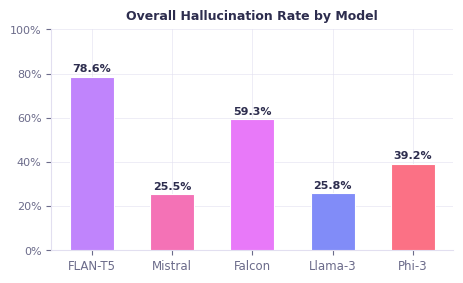

Saved → fig1_overall_hallucination_rate.png


In [ ]:
# Plot 1: Hallucination rate by model (overall)
fig, ax = plt.subplots(figsize=(4.6, 2.8))

present = [m for m in MODELS if m in all_results.keys()]
vals    = [(1 - all_results[m][0]["is_correct"].mean()) * 100 for m in present]
cols    = [MODEL_COLORS[m] for m in present]

bars = ax.bar(present, vals, color=cols, width=0.55, zorder=3,
              edgecolor="white", linewidth=0.8)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.2,
            f"{v:.1f}%", ha="center", va="bottom",
            fontsize=8, color=INK2, fontweight="bold")

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Overall Hallucination Rate by Model")
ax.tick_params(axis="x", labelsize=8.5)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig1_overall_hallucination_rate.png", **SAVEKW)
plt.show()
print(f"Saved \u2192 {'fig1_overall_hallucination_rate.png'}")

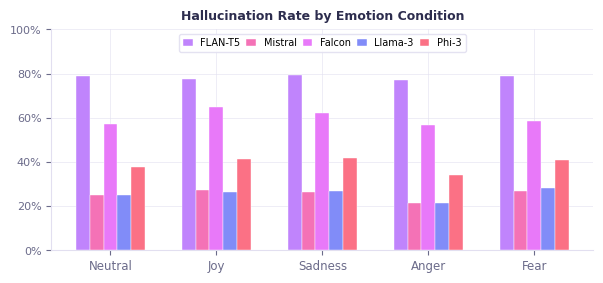

Saved → fig2_by_emotion_condition.png


In [ ]:
# Plot 2: Hallucination rate by emotion condition — grouped bars
fig, ax = plt.subplots(figsize=(6.0, 2.8))

present  = [m for m in MODELS if m in hr_emotion.columns]
n_e      = len(EMOTION_ORDER)
n_m      = len(present)
x        = np.arange(n_e)
w        = 0.13
offsets  = np.linspace(-(n_m - 1) / 2 * w, (n_m - 1) / 2 * w, n_m)

for i, model in enumerate(present):
    ax.bar(x + offsets[i], hr_emotion[model].values, w,
           color=MODEL_COLORS[model], zorder=3,
           edgecolor="white", linewidth=0.3, label=model)

ax.set_xticks(x)
ax.set_xticklabels([e.capitalize() for e in EMOTION_ORDER], fontsize=8.5)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Hallucination Rate by Emotion Condition")
ax.legend(fontsize=7, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          frameon=True, framealpha=0.9, edgecolor=GRID,
          handlelength=1, columnspacing=0.6)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig2_by_emotion_condition.png", **SAVEKW)
plt.show()
print("Saved → fig2_by_emotion_condition.png")

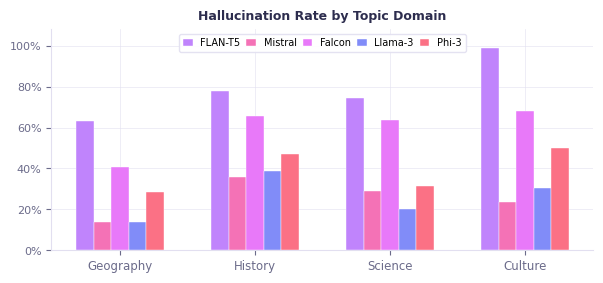

Saved → fig3_by_topic_domain.png


In [ ]:
# Plot 3: Hallucination rate by topic domain — grouped bars
fig, ax = plt.subplots(figsize=(6.0, 2.8))

present  = [m for m in MODELS if m in hr_domain.columns]
n_d      = len(DOMAIN_ORDER)
n_m      = len(present)
x        = np.arange(n_d)
w        = 0.13
offsets  = np.linspace(-(n_m - 1) / 2 * w, (n_m - 1) / 2 * w, n_m)

for i, model in enumerate(present):
    ax.bar(x + offsets[i], hr_domain[model].values, w,
           color=MODEL_COLORS[model], zorder=3,
           edgecolor="white", linewidth=0.3, label=model)

ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DOMAIN_ORDER], fontsize=8.5)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Hallucination Rate by Topic Domain")
ax.legend(fontsize=7, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          frameon=True, framealpha=0.9, edgecolor=GRID,
          handlelength=1, columnspacing=0.6)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig3_by_topic_domain.png", **SAVEKW)
plt.show()
print("Saved → fig3_by_topic_domain.png")

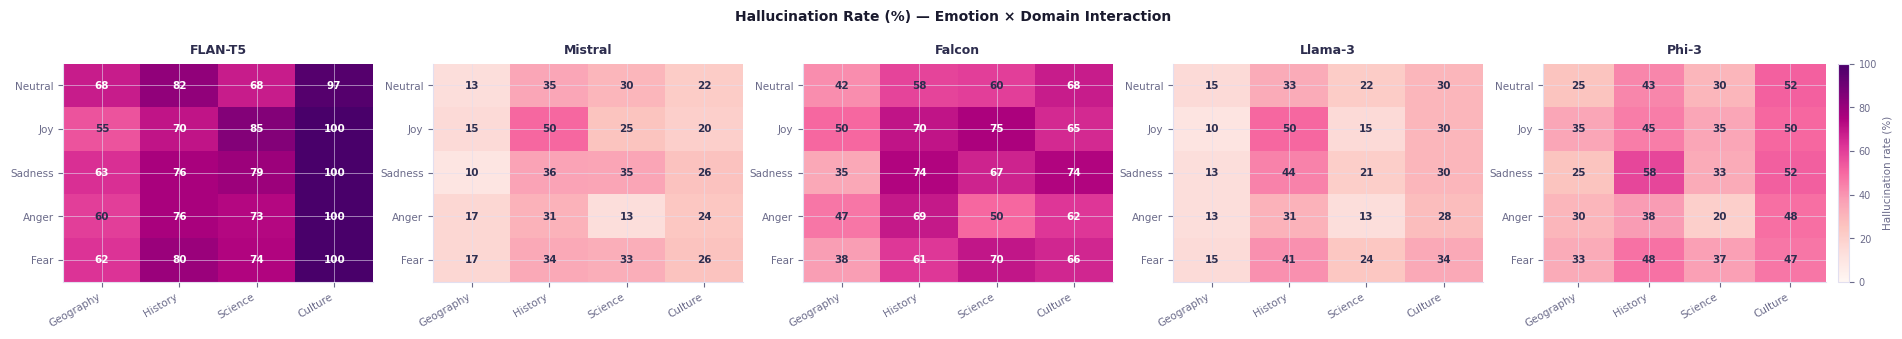

Saved → fig4_emotion_domain_heatmaps.png


In [ ]:
# Plot 4: Heatmaps — emotion x domain for each model (3-panel)
present = [m for m in MODELS if m in dfs]
n       = len(present)
cmap    = matplotlib.colormaps.get_cmap("RdPu")

fig, axes = plt.subplots(1, n, figsize=(3.8 * n, 3.2))
if n == 1:
    axes = [axes]

for ax, name in zip(axes, present):
    df = dfs[name]
    pivot = (
        df.groupby(["emotion_condition", "topic_domain"])["is_correct"]
        .apply(lambda x: 1 - x.mean()) # Calculate hallucination rate
        .unstack("topic_domain")
        .mul(100) # Convert to percentage
        .reindex(index=EMOTION_ORDER, columns=DOMAIN_ORDER)
    )

    im = ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=100, aspect="auto")

    # Annotate each cell
    for ri in range(len(EMOTION_ORDER)):
        for ci in range(len(DOMAIN_ORDER)):
            val = pivot.values[ri, ci]
            if np.isnan(val):
                continue
            text_col = "white" if val > 60 else INK2
            ax.text(ci, ri, f"{val:.0f}",
                    ha="center", va="center",
                    fontsize=7.5, color=text_col, fontweight="bold")

    ax.set_xticks(range(len(DOMAIN_ORDER)))
    ax.set_xticklabels([d.capitalize() for d in DOMAIN_ORDER],
                       fontsize=7.5, rotation=30, ha="right")
    ax.set_yticks(range(len(EMOTION_ORDER)))
    ax.set_yticklabels([e.capitalize() for e in EMOTION_ORDER], fontsize=7.5)
    ax.set_title(name, fontsize=9, fontweight="bold", color=INK2)

    if ax is axes[-1]:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=7)
        cbar.set_label("Hallucination rate (%)", fontsize=7.5, color=MUTED)

fig.suptitle("Hallucination Rate (%) — Emotion × Domain Interaction",
             fontsize=10, fontweight="bold", color=INK, y=1.02)
fig.tight_layout(pad=0.5)
fig.savefig(OUTPUT_DIR / "fig4_emotion_domain_heatmaps.png", **SAVEKW)
plt.show()
print("Saved → fig4_emotion_domain_heatmaps.png")

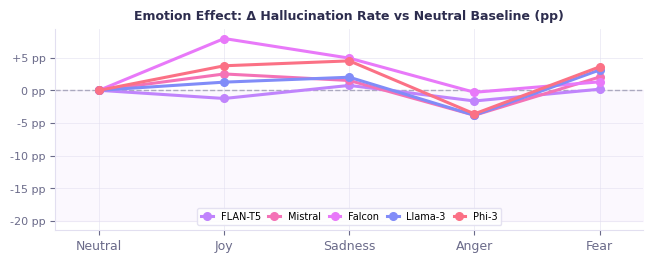

Saved → fig5_delta_from_neutral.png


In [ ]:
# Plot 5: Delta-from-neutral line chart
fig, ax = plt.subplots(figsize=(6.5, 2.6))

present = [m for m in MODELS if m in delta.columns]
x       = np.arange(len(delta))

for model in present:
    ax.plot(x, delta[model].values,
            color=MODEL_COLORS[model], marker="o", markersize=5.5,
            linewidth=2.2, label=model, zorder=3)

# Zero baseline & shading
ax.axhline(0, color=MUTED, linewidth=1, linestyle="--", alpha=0.5, zorder=2)
ax.fill_between([-0.4, len(delta) - 0.6], -20, 0,
                alpha=0.04, color="#a855f7", zorder=1)

ax.set_xticks(x)
ax.set_xticklabels([e.capitalize() for e in delta.index], fontsize=9)
ax.set_xlim(-0.35, len(delta) - 0.65)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"+{v:.0f} pp" if v > 0 else f"{v:.0f} pp")
)
ax.set_title("Emotion Effect: Δ Hallucination Rate vs Neutral Baseline (pp)")
ax.legend(fontsize=7, ncol=5, loc="lower center",
          frameon=True, framealpha=0.9, edgecolor=GRID,
          handlelength=1.2, columnspacing=0.8)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig5_delta_from_neutral.png", **SAVEKW)
plt.show()
print("Saved → fig5_delta_from_neutral.png")

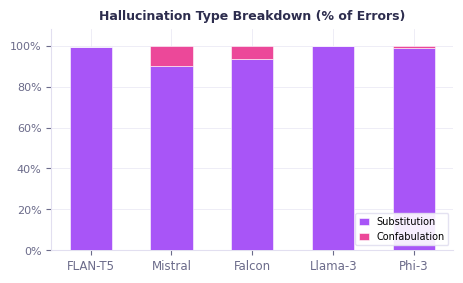

Saved → fig6_hallucination_type_breakdown.png


In [ ]:
# Plot 6: Hallucination type stacked bar chart
fig, ax = plt.subplots(figsize=(4.6, 2.8))

present = [m for m in MODELS if m in types.columns]
x       = np.arange(len(present))
w       = 0.52
bot     = np.zeros(len(present))

TYPE_LABELS = {
    "substitution":  "Substitution",
    "confabulation": "Confabulation",
    "uncertainty":   "Uncertainty",
    "refusal_empty": "Refusal / Empty",
}

for ttype, label in TYPE_LABELS.items():
    if ttype not in types.index:
        continue
    vals = types.loc[ttype, present].values
    if vals.sum() == 0:
        continue
    ax.bar(x, vals, w, bottom=bot, label=label,
           color=TYPE_COLORS[ttype], zorder=3,
           edgecolor="white", linewidth=0.4)
    bot += vals

ax.set_xticks(x)
ax.set_xticklabels(present, fontsize=8.5)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Hallucination Type Breakdown (% of Errors)")
ax.legend(fontsize=7, loc="lower right",
          frameon=True, framealpha=0.9, edgecolor=GRID, handlelength=1)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig6_hallucination_type_breakdown.png", **SAVEKW)
plt.show()
print("Saved → fig6_hallucination_type_breakdown.png")

In [ ]:
# Compute word-count length of each model response
for name, df in dfs.items():
    df["response_length"] = df["model_response"].fillna("").str.split().str.len()

# Summary statistics: mean & median length by correctness
print(f"{'Model':<12}  {'Correct mean':>13}  {'Correct med':>12}  {'Incorrect mean':>15}  {'Incorrect med':>13}")
print("-" * 72)
for name, df in dfs.items():
    correct   = df[df["is_correct"]]["response_length"]
    incorrect = df[~df["is_correct"]]["response_length"]
    print(f"{name:<12}  {correct.mean():>13.1f}  {correct.median():>12.1f}  {incorrect.mean():>15.1f}  {incorrect.median():>13.1f}")

Model          Correct mean   Correct med   Incorrect mean  Incorrect med
------------------------------------------------------------------------
FLAN-T5                 1.6           1.0              2.2            2.0
Mistral                 2.7           2.0              6.0            3.0
Falcon                  3.9           2.0              4.9            3.0
Llama-3                 1.6           1.0              1.8            2.0
Phi-3                   1.7           1.0              2.2            2.0


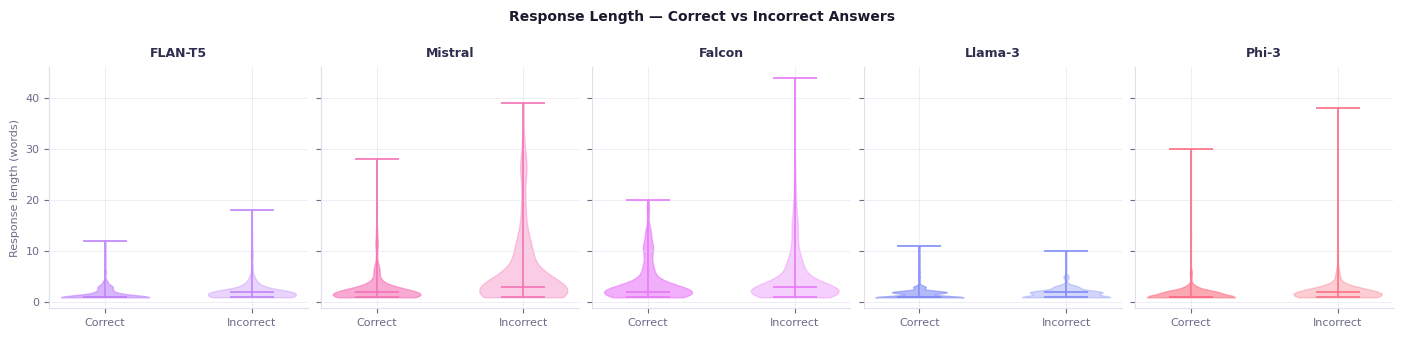

Saved → fig7_response_length_distributions.png


In [ ]:
# Plot 7 — Response length distributions: correct vs incorrect
present = [m for m in MODELS if m in dfs]
n_m     = len(present)

fig, axes = plt.subplots(1, n_m, figsize=(2.8 * n_m, 3.2), sharey=True)
if n_m == 1:
    axes = [axes]

for ax, name in zip(axes, present):
    df    = dfs[name]
    col   = MODEL_COLORS[name]
    data_correct   = df[df["is_correct"]]["response_length"].dropna()
    data_incorrect = df[~df["is_correct"]]["response_length"].dropna()

    vp = ax.violinplot(
        [data_correct, data_incorrect],
        positions=[0, 1],
        showmedians=True,
        widths=0.6,
    )
    # Colour each violin
    for i, body in enumerate(vp["bodies"]):
        body.set_facecolor(col)
        body.set_alpha(0.6 if i == 0 else 0.35)
        body.set_edgecolor(col)
    for part in ("cmedians", "cbars", "cmins", "cmaxes"):
        vp[part].set_color(col)
        vp[part].set_linewidth(1.2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Correct", "Incorrect"], fontsize=8)
    ax.set_title(name, fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("Response length (words)", fontsize=8, color=MUTED)

fig.suptitle("Response Length — Correct vs Incorrect Answers",
             fontsize=10, fontweight="bold", color=INK, y=1.02)
fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig7_response_length_distributions.png", **SAVEKW)
plt.show()
print("Saved → fig7_response_length_distributions.png")

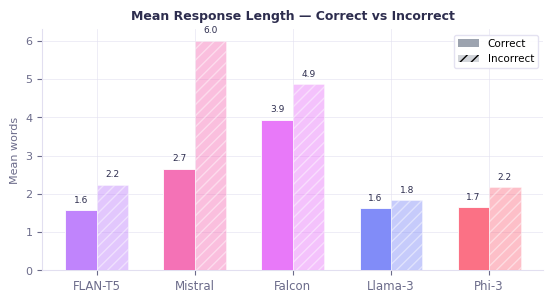

Saved → fig8_mean_length_correct_vs_incorrect.png


In [ ]:
# Plot 8 — Mean response length by model, correct vs incorrect
from matplotlib.patches import Patch

present = [m for m in MODELS if m in dfs]

means_correct   = [dfs[m][dfs[m]["is_correct"]]["response_length"].mean()  for m in present]
means_incorrect = [dfs[m][~dfs[m]["is_correct"]]["response_length"].mean() for m in present]

x  = np.arange(len(present))
w  = 0.32
fig, ax = plt.subplots(figsize=(5.5, 3.0))

bars_c = ax.bar(x - w / 2, means_correct,   w,
                color=[MODEL_COLORS[m] for m in present], zorder=3,
                edgecolor="white", linewidth=0.6)
bars_i = ax.bar(x + w / 2, means_incorrect, w,
                color=[MODEL_COLORS[m] for m in present], zorder=3,
                edgecolor="white", linewidth=0.6, alpha=0.45, hatch="///")

for bar, v in list(zip(bars_c, means_correct)) + list(zip(bars_i, means_incorrect)):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.15,
            f"{v:.1f}", ha="center", va="bottom", fontsize=6.5, color=INK2)

ax.set_xticks(x)
ax.set_xticklabels(present, fontsize=8.5)
ax.set_ylabel("Mean words", fontsize=8, color=MUTED)
ax.set_title("Mean Response Length — Correct vs Incorrect")

legend_elements = [
    Patch(facecolor="#9ca3af", label="Correct"),
    Patch(facecolor="#9ca3af", alpha=0.45, hatch="///", label="Incorrect"),
]
ax.legend(handles=legend_elements, fontsize=7.5, frameon=True,
          framealpha=0.9, edgecolor=GRID)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig8_mean_length_correct_vs_incorrect.png", **SAVEKW)
plt.show()
print("Saved → fig8_mean_length_correct_vs_incorrect.png")

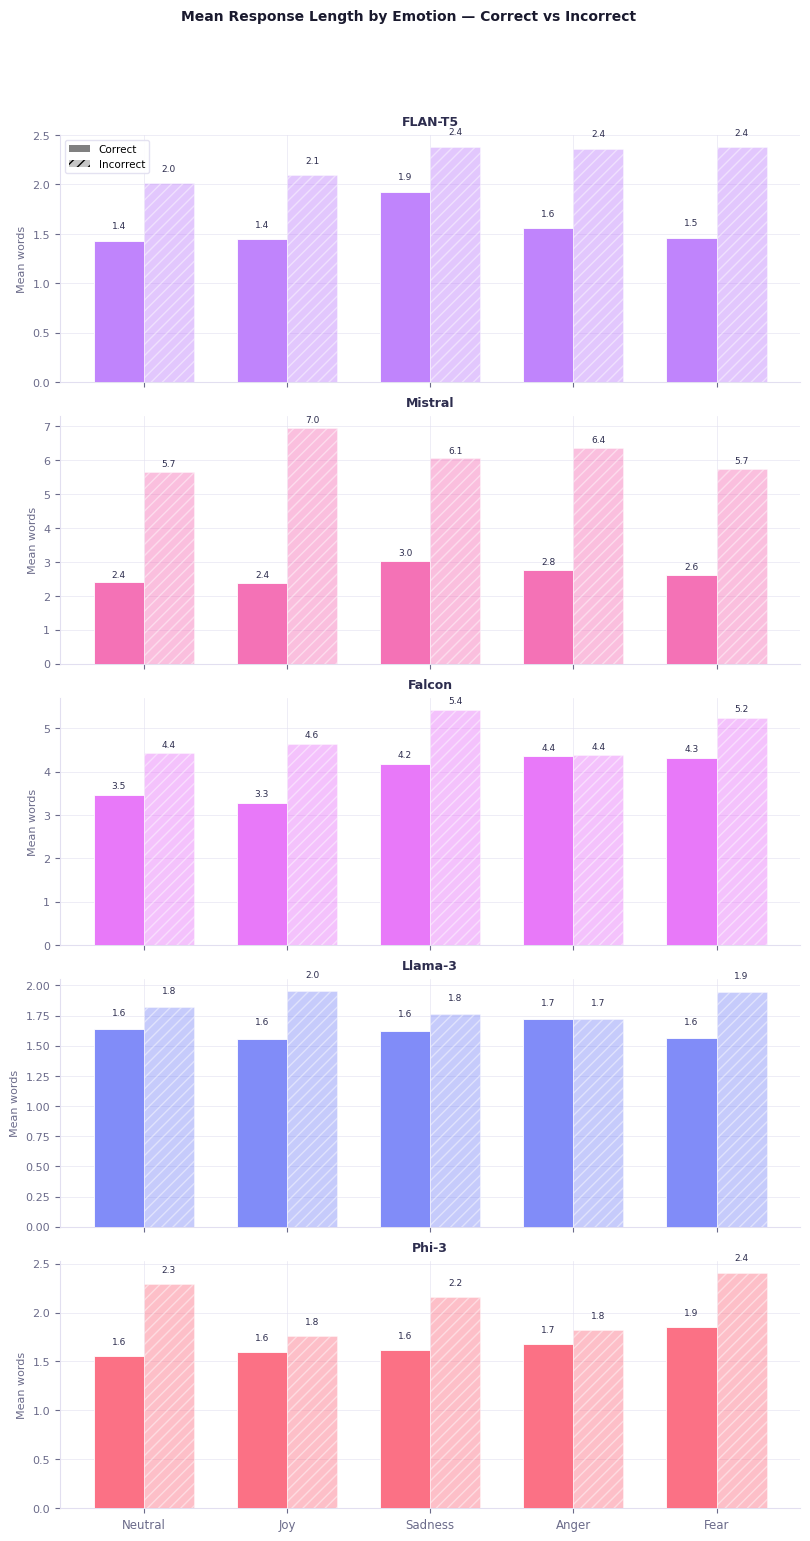

Saved → plots/fig9_mean_length_emotion_correctness.png


In [ ]:
# Prepare data for mean response length by emotion and correctness for all models
mean_lengths_by_emotion_correctness = []

for model_name, (df_m, _, _, _) in all_results.items():
    # Ensure response_length is calculated for this model's dataframe
    if "response_length" not in df_m.columns:
        df_m["response_length"] = df_m["model_response"].fillna("").str.split().str.len()

    for emotion in EMOTION_ORDER:
        df_emotion = df_m[df_m['emotion_condition'] == emotion]

        correct_lengths = df_emotion[df_emotion['is_correct']]['response_length'].mean()
        incorrect_lengths = df_emotion[~df_emotion['is_correct']]['response_length'].mean()

        mean_lengths_by_emotion_correctness.append({
            'Model': model_name,
            'Emotion': emotion,
            'Mean Length Correct': correct_lengths,
            'Mean Length Incorrect': incorrect_lengths
        })

df_mean_lengths = pd.DataFrame(mean_lengths_by_emotion_correctness)

# Plotting: Mean response length by emotion, correct vs incorrect, for each model
fig, axes = plt.subplots(len(MODELS), 1, figsize=(8, 3 * len(MODELS)), sharex=True)
if len(MODELS) == 1:
    axes = [axes]

for i, model_name in enumerate(MODELS):
    ax = axes[i]
    # Reindex to ensure all emotions are present in order for consistent plotting
    model_data = df_mean_lengths[df_mean_lengths['Model'] == model_name].set_index('Emotion').reindex(EMOTION_ORDER)

    x = np.arange(len(EMOTION_ORDER))
    w = 0.35 # bar width

    bars_correct = ax.bar(x - w/2, model_data['Mean Length Correct'], w, label="Correct",
                          color=MODEL_COLORS[model_name], zorder=3, edgecolor="white", linewidth=0.6)
    bars_incorrect = ax.bar(x + w/2, model_data['Mean Length Incorrect'], w, label="Incorrect",
                            color=MODEL_COLORS[model_name], alpha=0.45, hatch="///", zorder=3, edgecolor="white", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([e.capitalize() for e in EMOTION_ORDER], fontsize=8.5)
    ax.set_ylabel("Mean words", fontsize=8, color=MUTED)
    ax.set_title(f"{model_name}", fontsize=9, fontweight="bold", color=INK2)
    ax.tick_params(axis='y', labelsize=8)

    # Add mean values on top of bars
    for j, (bc, bi) in enumerate(zip(bars_correct, bars_incorrect)):
        if not pd.isna(model_data['Mean Length Correct'].iloc[j]):
            ax.text(bc.get_x() + bc.get_width()/2, bc.get_height() + 0.1,
                    f"{model_data['Mean Length Correct'].iloc[j]:.1f}", ha='center', va='bottom', fontsize=6.5, color=INK2)
        if not pd.isna(model_data['Mean Length Incorrect'].iloc[j]):
            ax.text(bi.get_x() + bi.get_width()/2, bi.get_height() + 0.1,
                    f"{model_data['Mean Length Incorrect'].iloc[j]:.1f}", ha='center', va='bottom', fontsize=6.5, color=INK2)

    if i == 0: # Add legend only once for the first subplot
        legend_elements = [
            Patch(facecolor="gray", label="Correct"),
            Patch(facecolor="gray", alpha=0.45, hatch="///", label="Incorrect"),
        ]
        ax.legend(handles=legend_elements, fontsize=7.5, frameon=True,
                  framealpha=0.9, edgecolor=GRID, loc='upper left')

fig.suptitle("Mean Response Length by Emotion — Correct vs Incorrect",
             fontsize=10, fontweight="bold", color=INK, y=1.02)
fig.tight_layout(pad=0.6, rect=[0, 0, 1, 0.97]) # Adjust rect to make space for suptitle
fig.savefig(OUTPUT_DIR / "fig9_mean_length_emotion_correctness.png", **SAVEKW)
plt.show()
print(f"Saved \u2192 {OUTPUT_DIR / 'fig9_mean_length_emotion_correctness.png'}")

---
## Section 11 — Statistical Analysis

Chi-squared tests + Cramér's V for emotion and domain effects, with Bonferroni-corrected pairwise domain comparisons, for each model.
Followed by a cross-model summary table.

In [ ]:
stats_results = {}
for model_name, (df_m, _, _, _) in all_results.items():
    stats_results[model_name] = run_statistical_tests(df_m, model_name)


STATISTICAL TESTS — FLAN-T5
  Emotion: chi2(4) = 0.322, p = 0.9883, V = 0.020 (negligible)
  Domain:  chi2(3) = 82.353, p = 0.0000, V = 0.316 (medium)

  Pairwise domain comparisons (Bonferroni alpha = 0.0083):
    geography    vs history     : chi2=9.741, p=0.0018  *
    geography    vs science     : chi2=5.516, p=0.0188  ns
    geography    vs culture     : chi2=83.826, p=0.0000  *
    history      vs science     : chi2=0.449, p=0.5027  ns
    history      vs culture     : chi2=43.106, p=0.0000  *
    science      vs culture     : chi2=51.761, p=0.0000  *
  (* = significant after Bonferroni correction)

STATISTICAL TESTS — Mistral
  Emotion: chi2(4) = 1.687, p = 0.7930, V = 0.045 (negligible)
  Domain:  chi2(3) = 28.363, p = 0.0000, V = 0.186 (small)

  Pairwise domain comparisons (Bonferroni alpha = 0.0083):
    geography    vs history     : chi2=26.055, p=0.0000  *
    geography    vs science     : chi2=13.230, p=0.0003  *
    geography    vs culture     : chi2=6.155, p=0.0131  ns

### Cross-Model Statistical Summary

In [ ]:
rows = []
for model_name, s in stats_results.items():
    rows.append({
        'Model':        model_name,
        'Emotion chi2': f"{s['chi2_e']:.3f}",
        'Emotion p':    f"{s['p_e']:.4f}",
        'Emotion V':    f"{s['v_e']:.3f} ({s['interp_e']})",
        'Domain chi2':  f"{s['chi2_d']:.3f}",
        'Domain p':     f"{s['p_d']:.4f}",
        'Domain V':     f"{s['v_d']:.3f} ({s['interp_d']})",
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('\nCross-model statistical summary:')
print(summary_df.to_string())
summary_df


Cross-model statistical summary:
        Emotion chi2 Emotion p           Emotion V Domain chi2 Domain p        Domain V
Model                                                                                  
FLAN-T5        0.322    0.9883  0.020 (negligible)      82.353   0.0000  0.316 (medium)
Mistral        1.687    0.7930  0.045 (negligible)      28.363   0.0000   0.186 (small)
Falcon         2.545    0.6366  0.056 (negligible)      42.139   0.0000  0.226 (medium)
Llama-3        2.067    0.7234  0.050 (negligible)      39.980   0.0000  0.220 (medium)
Phi-3          2.754    0.5997  0.058 (negligible)      30.841   0.0000   0.194 (small)


,Emotion chi2,Emotion p,Emotion V,Domain chi2,Domain p,Domain V
Model,,,,,,
FLAN-T5,0.322,0.9883,0.020 (negligible),82.353,0.0000,0.316 (medium)
Mistral,1.687,0.7930,0.045 (negligible),28.363,0.0000,0.186 (small)
Falcon,2.545,0.6366,0.056 (negligible),42.139,0.0000,0.226 (medium)
Llama-3,2.067,0.7234,0.050 (negligible),39.980,0.0000,0.220 (medium)
Phi-3,2.754,0.5997,0.058 (negligible),30.841,0.0000,0.194 (small)


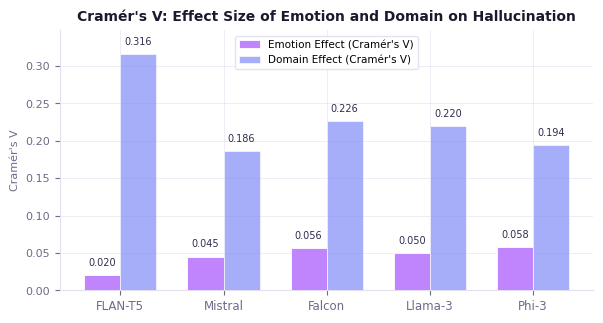

Saved → plots/fig10_cramers_v_stats.png


In [ ]:
# Extract numerical V values from summary_df
plot_df = summary_df.copy()
plot_df['Emotion V_num'] = plot_df['Emotion V'].apply(lambda x: float(x.split(' ')[0]))
plot_df['Domain V_num'] = plot_df['Domain V'].apply(lambda x: float(x.split(' ')[0]))

# Prepare data for plotting
plot_data = plot_df[['Emotion V_num', 'Domain V_num']]

# Plotting
fig, ax = plt.subplots(figsize=(6.0, 3.2))

models = plot_data.index.tolist()
x = np.arange(len(models))
w = 0.35 # bar width

bars_emotion = ax.bar(x - w/2, plot_data['Emotion V_num'], w, label="Emotion Effect (Cramér's V)",
                      color=MODEL_COLORS['FLAN-T5'], zorder=3, edgecolor="white", linewidth=0.6)
bars_domain = ax.bar(x + w/2, plot_data['Domain V_num'], w, label="Domain Effect (Cramér's V)",
                     color=MODEL_COLORS['Llama-3'], alpha=0.7, zorder=3, edgecolor="white", linewidth=0.6)

# Add V values on top of bars
for bars in [bars_emotion, bars_domain]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
                f'{yval:.3f}', ha='center', va='bottom', fontsize=7, color=INK2)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=8.5)
ax.set_ylabel("Cramér's V", fontsize=8, color=MUTED)
ax.set_title("Cramér's V: Effect Size of Emotion and Domain on Hallucination", fontsize=10, fontweight="bold", color=INK)
ax.set_ylim(0, plot_data[['Emotion V_num', 'Domain V_num']].max().max() * 1.1)
ax.legend(fontsize=7.5, loc="upper center", frameon=True, framealpha=0.9, edgecolor=GRID)

fig.tight_layout(pad=0.6)
fig.savefig(OUTPUT_DIR / "fig10_cramers_v_stats.png", **SAVEKW)
plt.show()
print(f"Saved → {OUTPUT_DIR / 'fig10_cramers_v_stats.png'}")

---
## Section 12 — Qualitative Analysis

For each model: find questions that were answered correctly in the neutral condition but incorrectly in at least one emotional condition. These cases are the most direct evidence of emotion-induced errors.

In [ ]:
for model_name, (df_m, _, _, _) in all_results.items():
    neutral_correct = df_m[
        (df_m['emotion_condition'] == 'neutral') & (df_m['is_correct'] == True)
    ]['question_id'].tolist()

    has_emotional_error = df_m[
        (df_m['emotion_condition'] != 'neutral') &
        (df_m['is_correct'] == False) &
        (df_m['question_id'].isin(neutral_correct))
    ]['question_id'].unique()

    pct = len(has_emotional_error) / len(neutral_correct) * 100 if neutral_correct else 0
    print(f'\n{"="*70}')
    print(f'MODEL: {model_name}')
    print(f'Questions correct in neutral but wrong in >=1 emotional condition: '
          f'{len(has_emotional_error)} ({pct:.1f}% of neutral-correct questions)')

    shown = 0
    for qid in has_emotional_error:
        if shown >= 5:
            break
        subset = df_m[df_m['question_id'] == qid].set_index('emotion_condition')
        if 'neutral' not in subset.index or not subset.loc['neutral', 'is_correct']:
            continue
        neutral_row = subset.loc['neutral']
        print(f"\n  ID: {qid} | Domain: {neutral_row['topic_domain']} | Truth: {neutral_row['ground_truth']}")
        print(f"  [neutral ] {neutral_row['model_response']}  (correct)")
        for emotion in ['joy', 'sadness', 'anger', 'fear']:
            if emotion not in subset.index:
                continue
            row = subset.loc[emotion]
            if not row['is_correct']:
                print(f"  [{emotion:7s}] {row['model_response']}  (wrong — {row['hallucination_type']})")
        print(f"  {'-'*60}")
        shown += 1


MODEL: FLAN-T5
Questions correct in neutral but wrong in >=1 emotional condition: 19 (37.3% of neutral-correct questions)

  ID: odql_4256 | Domain: geography | Truth: MILAN
  [neutral ] milan  (correct)
  [sadness] venice  (wrong — substitution)
  ------------------------------------------------------------

  ID: bt_3953 | Domain: geography | Truth: Liverpool
  [neutral ] Liverpool  (correct)
  [fear   ] Manchester  (wrong — substitution)
  ------------------------------------------------------------

  ID: dpql_3255 | Domain: geography | Truth: Bulgaria
  [neutral ] bulgaria  (correct)
  [sadness] croatia  (wrong — substitution)
  [anger  ] croatia  (wrong — substitution)
  [fear   ] croatia  (wrong — substitution)
  ------------------------------------------------------------

  ID: odql_3672 | Domain: geography | Truth: CUBA
  [neutral ] cuba  (correct)
  [sadness] Jamaica  (wrong — substitution)
  [fear   ] Jamaica  (wrong — substitution)
  --------------------------------------

In [ ]:
print('=' * 70)
print('FINAL RESULTS SUMMARY — ALL MODELS')
print('=' * 70)
print(f"\n{'Model':<12} {'Accuracy':>10} {'Hallucination':>14} {'Emotion V':>10} {'Domain V':>10}")
print('-' * 60)
for model_name, (df_m, _, _, _) in all_results.items():
    acc = df_m['is_correct'].mean()
    s   = stats_results[model_name]
    print(f"{model_name:<12} {acc:>10.1%} {1-acc:>14.1%} {s['v_e']:>10.3f} {s['v_d']:>10.3f}")
print('=' * 70)

FINAL RESULTS SUMMARY — ALL MODELS

Model          Accuracy  Hallucination  Emotion V   Domain V
------------------------------------------------------------
FLAN-T5           21.4%          78.6%      0.020      0.316
Mistral           74.5%          25.5%      0.045      0.186
Falcon            40.7%          59.3%      0.056      0.226
Llama-3           74.2%          25.8%      0.050      0.220
Phi-3             60.8%          39.2%      0.058      0.194


In [ ]:
## EVERY RESULT

print('=' * 70)
print('FINAL RESULTS SUMMARY — ALL MODELS')
print('=' * 70)
print(f"\n{'Model':<12} {'Accuracy':>10} {'Hallucination':>14} {'Emotion V':>10} {'Domain V':>10}")
print('-' * 60)
for model_name, (df_m, _, _, _) in all_results.items():
    acc = df_m['is_correct'].mean()
    s   = stats_results[model_name]
    print(f"{model_name:<12} {acc:>10.1%} {1-acc:>14.1%} {s['v_e']:>10.3f} {s['v_d']:>10.3f}")
print('=' * 70)

print('\nCross-model statistical summary:')
display(summary_df)


print('\nQualitative Results:')
for model_name, (df_m, _, _, _) in all_results.items():
    neutral_correct = df_m[
        (df_m['emotion_condition'] == 'neutral') & (df_m['is_correct'] == True)
    ]['question_id'].tolist()

    has_emotional_error = df_m[
        (df_m['emotion_condition'] != 'neutral') &
        (df_m['is_correct'] == False) &
        (df_m['question_id'].isin(neutral_correct))
    ]['question_id'].unique()

    pct = len(has_emotional_error) / len(neutral_correct) * 100 if neutral_correct else 0
    print(f'\n{"="*70}')
    print(f'MODEL: {model_name}')
    print(f'Questions correct in neutral but wrong in >=1 emotional condition: '
          f'{len(has_emotional_error)} ({pct:.1f}% of neutral-correct questions)')

    shown = 0
    for qid in has_emotional_error:
        if shown >= 3: # Limit to 3 examples per model for brevity
            break
        subset = df_m[df_m['question_id'] == qid].set_index('emotion_condition')
        if 'neutral' not in subset.index or not subset.loc['neutral', 'is_correct']:
            continue
        neutral_row = subset.loc['neutral']
        print(f"\n  ID: {qid} | Domain: {neutral_row['topic_domain']} | Truth: {neutral_row['ground_truth']}")
        print(f"  [neutral ] {neutral_row['model_response']}  (correct)")
        for emotion in ['joy', 'sadness', 'anger', 'fear']:
            if emotion not in subset.index:
                continue
            row = subset.loc[emotion]
            if not row['is_correct']:
                print(f"  [{emotion:7s}] {row['model_response']}  (wrong — {row['hallucination_type']})")
        print(f"  {'-'*60}")
        shown += 1

FINAL RESULTS SUMMARY — ALL MODELS

Model          Accuracy  Hallucination  Emotion V   Domain V
------------------------------------------------------------
FLAN-T5           21.4%          78.6%      0.020      0.316
Mistral           74.5%          25.5%      0.045      0.186
Falcon            40.7%          59.3%      0.056      0.226
Llama-3           74.2%          25.8%      0.050      0.220
Phi-3             60.8%          39.2%      0.058      0.194

Cross-model statistical summary:


,Emotion chi2,Emotion p,Emotion V,Domain chi2,Domain p,Domain V
Model,,,,,,
FLAN-T5,0.322,0.9883,0.020 (negligible),82.353,0.0000,0.316 (medium)
Mistral,1.687,0.7930,0.045 (negligible),28.363,0.0000,0.186 (small)
Falcon,2.545,0.6366,0.056 (negligible),42.139,0.0000,0.226 (medium)
Llama-3,2.067,0.7234,0.050 (negligible),39.980,0.0000,0.220 (medium)
Phi-3,2.754,0.5997,0.058 (negligible),30.841,0.0000,0.194 (small)



Qualitative Results:

MODEL: FLAN-T5
Questions correct in neutral but wrong in >=1 emotional condition: 19 (37.3% of neutral-correct questions)

  ID: odql_4256 | Domain: geography | Truth: MILAN
  [neutral ] milan  (correct)
  [sadness] venice  (wrong — substitution)
  ------------------------------------------------------------

  ID: bt_3953 | Domain: geography | Truth: Liverpool
  [neutral ] Liverpool  (correct)
  [fear   ] Manchester  (wrong — substitution)
  ------------------------------------------------------------

  ID: dpql_3255 | Domain: geography | Truth: Bulgaria
  [neutral ] bulgaria  (correct)
  [sadness] croatia  (wrong — substitution)
  [anger  ] croatia  (wrong — substitution)
  [fear   ] croatia  (wrong — substitution)
  ------------------------------------------------------------

MODEL: Mistral
Questions correct in neutral but wrong in >=1 emotional condition: 14 (7.8% of neutral-correct questions)

  ID: qb_7598 | Domain: geography | Truth: Goat Island
  [neutr